<a href="https://colab.research.google.com/github/vn322/bag_of_bats/blob/main/%D0%BC%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%81%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Математическая статистика 2**

**Ключевые слова**: центральная предельная теорема, нулевая гипотеза, доверительные интервалы, t-распределение

**Программа лекции:**

1. Центральная предельная теорема
2. Доверительные интервалы
3. Проверка гипотез
4. t-распределение

**Описательная статистика**, о которой мы говорили в первой лекции, обычно не вызывает вопросов. Однако, когда мы переходим к **индуктивной статистике** и проверке гипотез, абстрактные отношения между выборкой и генеральной совокупностью (популяцией) начинают играть ключевую роль. Эти абстрактные нюансы не стоит проходить впопыхах; нужно уделить им время и вдумчиво их усвоить.

Сначала давайте начнем с теоремы, которая закладывает основу для всей индуктивной статистики, а именно — с центральной предельной теоремы.

# Центральная предельная теорема

Одной из причин, по которой **нормальное распределение** важно, является то, что оно часто встречается в природе, например, в весах **взрослых золотистых ретриверов**. Однако оно возникает и в более интересном контексте за пределами естественных популяций. Когда мы начинаем измерять достаточно большие **выборки** из **популяции**, даже если эта **популяция** не следует **нормальному распределению**, **нормальное распределение** все равно возникает.

Предположим, мы измеряем **генеральную совокупность** (**популяцию**), которая действительно является равномерно случайной. Любое значение между **0.0** и **1.0** имеет одинаковую вероятность, и ни одно значение не имеет предпочтения. Но происходит нечто интересное, когда мы берем все более крупные выборки из этой популяции, берем среднее каждой выборки и затем строим их гистограмму. Запустите этот Python-код в *примере 1* и посмотрите на график.


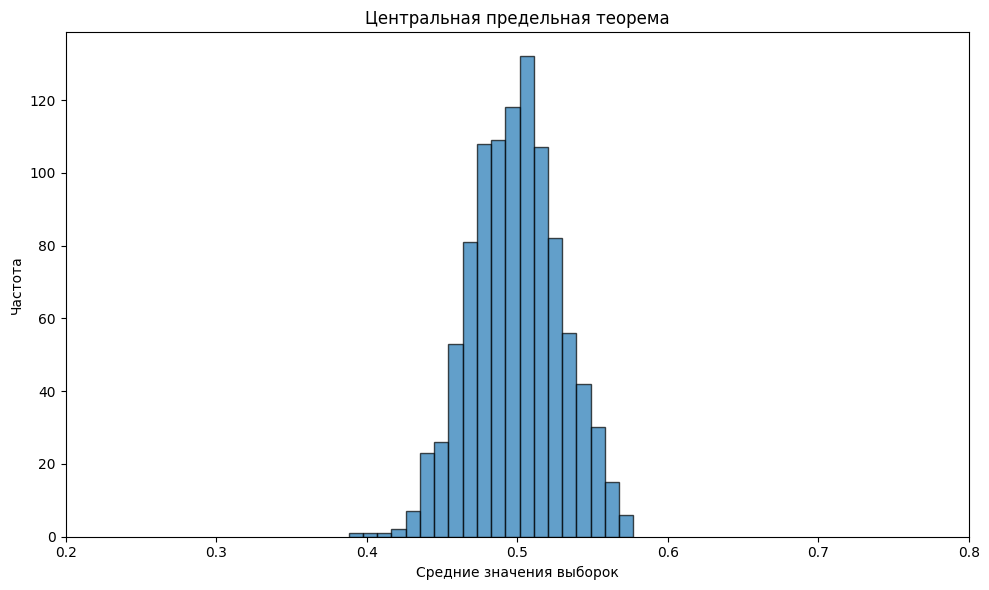

In [ ]:
# Пример 1: Исследование центральной предельной теоремы на Python
# Выборки из равномерного распределения будут усредняться до нормального распределения.
import random
import matplotlib.pyplot as plt

sample_size = 100
sample_count = 1000

# Центральная предельная теорема: 1000 выборок по 1 случайному числу между 0.0 и 1.0
x_values = [(sum([random.uniform(0.0, 1.0) for i in range(sample_size)]) / sample_size)
            for _ in range(sample_count)]

# Создаем гистограмму
plt.figure(figsize=(10, 6))
plt.hist(x_values, bins=20, edgecolor='black', alpha=0.7)

# Устанавливаем названия осей и заголовок на русском
plt.xlabel('Средние значения выборок')
plt.xlim([0.2, 0.8])
plt.ylabel('Частота')
plt.title('Центральная предельная теорема')

# Отображаем гистограмму
plt.tight_layout()
plt.show()

Подождите, как случайные числа из равномерного распределения от **0** до **1**, если их брать группами по **31** и затем **усреднять**, формируют **нормальное распределение**? Любое число имеет одинаковую вероятность, верно? Разве распределение не должно быть "плоским", а не колоколообразным?

Вот что происходит. Отдельные числа в выборках сами по себе не создадут **нормальное распределение**. Распределение будет "плоским", где любое число имеет одинаковую вероятность (это известно как **равномерное распределение**). Но когда мы группируем их в выборки и усредняем, они формируют **нормальное распределение**.

Это объясняется **центральной предельной теоремой** (ЦПТ), которая утверждает, что когда мы берем достаточно большие **выборки** из **популяции** (**генеральной совокупности**), рассчитываем среднее каждой и строим их распределение:

1. **Среднее выборок** равно **среднему значению популяции**.
2. Если популяция **нормально распределена**, то и **выборочные средние** будут нормально распределены.
3. Если популяция не является нормально распределенной, то при размере выборки больше 30, **средние значения выборок** все равно формируют **нормальное распределение**.
4. **Стандартное отклонение** средних значений выборок равно **стандартному отклонению** популяции, деленному на квадратный корень из **размера выборки** (**n**).

$$
\text{стандартное отк. выборки} = \frac{\text{стандартное откл. популяции}}{\sqrt{\text{размер выборки}}}
$$

Почему все вышесказанное **ОЧЕНЬ** важно? Эти свойства позволяют нам делать выводы о **популяциях** (**генеральных совокупностях**) на основе **выборок**, даже если популяции не имеют нормального распределения. Если вы измените приведенный выше код и попробуете меньшие размеры выборок - 1 или 2, вы не увидите нормального распределения. Но по мере приближения к размеру выборки **31** или более, вы увидите, что мы постепенно приходим к **нормальному распределению**. **Тридцать один** - это классическое число в статистике, потому что именно тогда наше выборочное распределение часто совпадает с популяционным распределением, особенно когда мы измеряем **средние выборок** или другие параметры. Когда у вас в выборке меньше **31** элемента, в этом случае вы должны использовать **t-распределение** вместо нормального распределения, которое имеет все более **толстые хвосты** с уменьшением размера выборки. Мы кратко поговорим об этом распределении позже, но сначала давайте предположим, что в наших выборках есть как минимум **31** элемент, когда мы можем говорить о **доверительных интервалах** и **тестировании гипотез**.

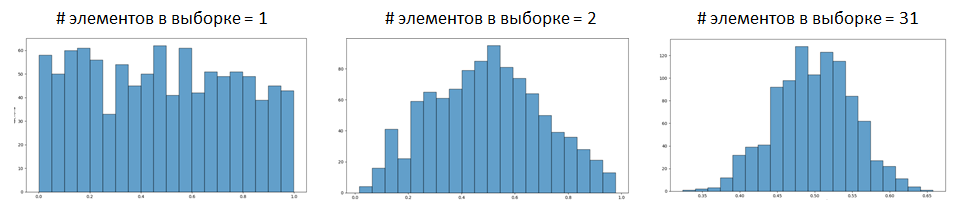

In [ ]:
#@title <b> Рисунок </b>
import gdown
from IPython.display import Image, display
google_drive_url = "https://drive.google.com/file/d/135mQpnyL4YEK5d-U5VIEiWtKIUCG0eGH/view?usp=drive_link"
file_id = google_drive_url.split('/')[5]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = 'downloaded_image.png'
gdown.download(download_url, output, quiet=True);
display(Image(output, width=1000))  # Adjust the width as needed

Рисунок 1. Больший размер выборки приводить к нормальному распределению средних выборок.

# Доверительные интервалы

Вы, возможно, слышали термин **"доверительный интервал"**, который часто сбивает с толку новичков в статистике. **Доверительный интервал** - это расчет диапазона, показывающий, насколько уверенно мы полагаем, что среднее значение выборки (или любой другой параметр) попадает в диапазон для среднего значения популяции (или любого другого параметра популяции).

Основываясь на выборке из **31го** золотистого ретривера со средним значением выборки **29.22** кг и стандартным отклонением выборки 0.93 кг, я на 95% уверен, что среднее значение популяции находится в диапазоне от **28.50** до **29.93** кг. Как мы это знаю? Давайте разбираться.

Сначала необходимо выбрать уровень доверия (*англ. level of confindence - LOC*), который будет содержать желаемую вероятность для диапазона среднего значения **популяции** (здесь важно помнить, что популяция и выборка — это не одно и то же). Мы хотим быть на **95%** уверены, что среднее значение выборки попадает в расчетный диапазон среднего значения популяции. Это мой **LOC**. Мы можем использовать **ЦПТ** и определить этот диапазон для среднего значения популяции. Во-первых, мне нужно критическое **z-значение**, которое представляет симметричный диапазон в стандартном нормальном распределении, дающий мне **95%** вероятности в центре, как показано на *рисунке 2*.



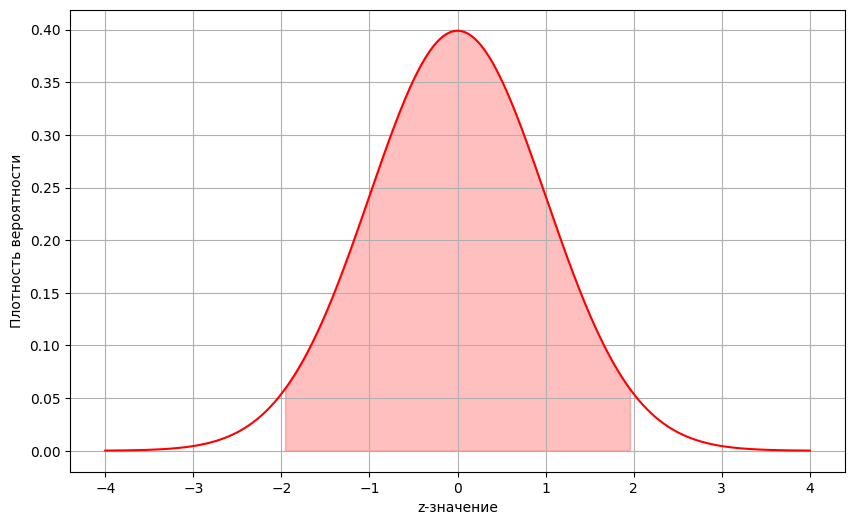

In [ ]:
#@title <b> Рисунок </b>
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Параметры нормального распределения
mean = 0
std_dev = 1

# Генерируем данные для графика
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, mean, std_dev)

# Устанавливаем границы для 95% вероятности
z1 = stats.norm.ppf(0.025, mean, std_dev)
z2 = stats.norm.ppf(0.975, mean, std_dev)

# Создаем график
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Нормальное распределение (среднее=0, дисперсия=1)', color='red')

# Закраска области 95% вероятности
plt.fill_between(x, y, where=(x >= z1) & (x <= z2), color='red', alpha=0.25, label='95% вероятность')

# Устанавливаем названия осей и заголовок на русском
plt.xlabel('z-значение')
plt.ylabel('Плотность вероятности')
#plt.title('Нормальное распределение со средним 0 и дисперсией 1\nЗакрашенная область 95% вероятности')
#plt.legend()

# Отображаем график
plt.grid(True)
plt.show()

Рисунок 2. 95% симметричная вероятность


Как рассчитать этот симметричный диапазон, содержащий **95%** закрашенной области?

Используем обратную функцию распределения. Логически, чтобы получить **95%** в симметричной области в центре, мы отсекаем хвосты, которые содержат оставшиеся **5%** площади. Разделив эти оставшиеся **5%** области пополам, мы получим по **2.5%** области в каждом хвосте. Мы можем вычислить **x-значения** для областей **0.025** и **0.975**, и это даст нам наш центр, содержащий **95%** области. Затем мы вернем соответствующие нижнее и верхнее **z-значения**, содержащие эту область. Помните, здесь мы используем стандартное нормальное распределение, так что значения будут одинаковыми, за исключением знака. Давайте рассчитаем это на **Python**, как показано в *примере 2*.

In [ ]:
# Пример 2
from scipy.stats import norm

def critical_z_value(p):
    norm_dist = norm(loc=0.0, scale=1.0)
    left_tail_area = (1.0 - p) / 2.0
    upper_area = 1.0 - left_tail_area
    return norm_dist.ppf(left_tail_area), norm_dist.ppf(upper_area)

print(critical_z_value(p=.95))
# (-1.959963984540054, 1.959963984540054)

(-1.959963984540054, 1.959963984540054)



Получаем $±1.95996$, что является нашим критическим **z-значением**, которое охватывает **95%** вероятности в центре стандартного нормального распределения. Далее воспользуемся центральной предельной теоремой для получения величины погрешности (**E**), которая представляет диапазон вокруг среднего значения выборки, содержащий среднее значение популяции на этом уровне доверия. Напомню, что наша выборка из **31** золотистого ретривера имеет среднее значение **29.22** кг и стандартное отклонение **0.93** кг. Формула для получения величины погрешности:

$$
E = \pm z \frac{s}{\sqrt{n}}
$$

$$
E = \pm 1.95996 \times \frac{0.93}{\sqrt{31}}
$$

$$
E = \pm 0.3273 \text{ кг}
$$

Применяя эту величину погрешности к среднему значению выборки, мы наконец получаем **доверительный интервал**!

$$
95\% \ \text{доверительный интервал} = 29.22 \pm 0.3273 \ кг
$$

Вот как мы рассчитываем этот доверительный интервал на **Python** от начала до конца в *примере 3*.

In [ ]:
# Пример 4-4
from math import sqrt
from scipy.stats import norm

def critical_z_value(p):
    norm_dist = norm(loc=0.0, scale=1.0)
    left_tail_area = (1.0 - p) / 2.0
    upper_area = 1.0 - left_tail_area
    return norm_dist.ppf(left_tail_area), norm_dist.ppf(upper_area)

def confidence_interval(p, sample_mean, sample_std, n):
    # Размер выборки должен быть больше 30
    lower, upper = critical_z_value(p)
    lower_ci = lower * (sample_std / sqrt(n))
    upper_ci = upper * (sample_std / sqrt(n))
    return sample_mean + lower_ci, sample_mean + upper_ci

print(confidence_interval(p=.95, sample_mean=29.22, sample_std=0.93, n=31))
# (28.8927, 29.5473)

(28.892621471233426, 29.547378528766572)


Вот как мы описываем наш доверительный интервал: "на основе моей выборки из **31** золотистого ретривера с выборочным средним значением **29.22** кг и выборочным стандартным отклонением **0.93** кг, я на **95%** уверен, что среднее значение популяции находится между **28.8927** и **29.5473 кг**".

**Интересный факт**: в нашей формуле величины погрешности, чем больше $\mathbf{n}$, тем уже наш доверительный интервал становится! Это логично, потому что при большей выборке мы более уверены, что среднее значение популяции находится в меньшем диапазоне и должно быть близко к среднему в выборке.

Одна важная оговорка заключается в том, что для этой оценки размер нашей выборки должен быть не менее **31** элемента. Это связано с **ЦПТ**. Если мы хотим применить доверительный интервал к меньшей выборке, нам нужно использовать распределение с большей дисперсией (с более толстыми хвостами, отражающими большую неопределенность). Для этого используется *t-распределение*, к которому мы еще вернемся.

# P-значение
Когда мы говорим, что что-то **статистически значимо**, что мы имеем в виду? Это выражение часто используется, но что оно означает с математической точки зрения? Концепция p-значения может стать более ясной, если вернуться к моменту её изобретения. Хотя это не идеальный пример, он помогает объяснить основные идеи.

В **1925** году математик **Рональд Фишер** был на вечеринке. Одна из его знакомых, **Мюриэль Бристоль**, утверждала, что может определить, налит ли чай первым или молоко, просто попробовав напиток. Заинтересованный её утверждением, **Рональд** устроил эксперимент прямо на месте.

Он подготовил восемь чашек чая. В **четырёх** из них молоко было налито первым, в других **четырё**х — чай. Затем он предоставил эти чашки Мюриэль и попросил её определить порядок наливания для каждой. Удивительно, но она правильно определила все чашки, и вероятность того, что это произошло случайно, составляет **1** к **70**, или **0,01428571**. Эта вероятность в **1,4%** называется **p-значением**, то есть вероятностью того, что что-то произошло совершенно случайно, а не по какой-то гипотетической причине.

Когда мы проводим эксперименты, будь то тестирование влияния пончиков на набор веса или влияния близости к линиям электропередач на возникновение рака, мы всегда должны учитывать возможность простой удачи. Так же, как в данном случае существует вероятность **1,4%**, что Мюриэль угадала верный порядок наливания случайно, всегда есть вероятность, что случайность окажет влияние на результаты эксперимента. Это помогает нам формулировать **нулевую гипотезу** (**H0**), утверждая, что исследуемая переменная не имеет влияния на эксперимент, и любые результаты являются случайными. **Альтернативная гипотеза** (**H1**) предполагает, что исследуемая переменная (контролируемая переменная) оказывает положительное воздействие.

Традиционно порог статистической значимости — это **p-значение** **5%** или меньше, или **0,05**. Поскольку 0,014 меньше 0,05, это означает, что мы можем отвергнуть **нулевую гипотезу** о том, что Мюриэль угадала случайно. Мы можем предположить **альтернативную гипотезу**, что у Мюриэль есть **уникальные способности** определять порядок наливания чая и молока.  


# Проверка гипотез

Давайте рассмотрим проверку гипотезы на конкретном примере. Пусть прошлые исследования показали, что среднее время выздоровления от простуды составляет 18 дней с отклонением в 1,5 дня, и что это время подчиняется нормальному распределению. Это означает, что вероятность выздоровления в течение от 15 до 21 дней составляет примерно 95%, как показано на *рисунке 4* и в *примере 5*.

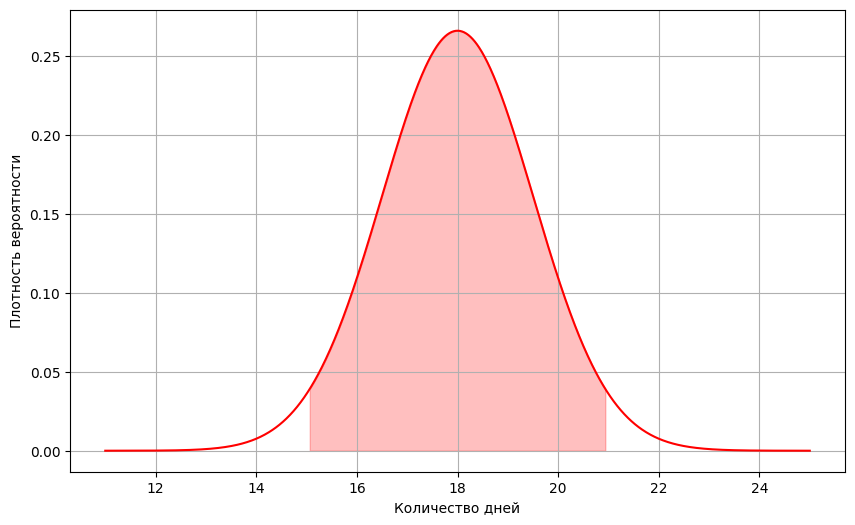

In [ ]:
#@title <b> Рисунок </b>
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Параметры нормального распределения
mean = 18
std_dev = 1.5

# Генерируем данные для графика
x = np.linspace(11, 25, 1000)
y = stats.norm.pdf(x, mean, std_dev)

# Устанавливаем границы для 95% вероятности
z1 = stats.norm.ppf(0.025, mean, std_dev)
z2 = stats.norm.ppf(0.975, mean, std_dev)

# Создаем график
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Нормальное распределение (среднее=0, дисперсия=1)', color='red')

# Закраска области 95% вероятности
plt.fill_between(x, y, where=(x >= z1) & (x <= z2), color='red', alpha=0.25, label='95% вероятность')

# Устанавливаем названия осей и заголовок на русском
plt.xlabel('Количество дней')
plt.ylabel('Плотность вероятности')
#plt.title('Нормальное распределение со средним 0 и дисперсией 1\nЗакрашенная область 95% вероятности')
#plt.legend()

# Отображаем график
plt.grid(True)
plt.show()

Рисунок 4. Вероятность выздоровления в период от 15 до 21 дня составляет 95%.

In [ ]:
# Пример 5
from scipy.stats import norm
# Простуда имеет среднее время выздоровления 18 дней, стандартное отклонение 1,5
mean = 18
std_dev = 1.5
# 95% вероятность того, что время выздоровления займет от 15 до 21 дней.
x = norm.cdf(21, mean, std_dev) - norm.cdf(15, mean, std_dev)
print(x) # 0.9544997361036416

0.9544997361036416



Из оставшихся **5%** вероятности можно сделать вывод, что есть **2,5%** шанс выздоровления дольше **21** дня и **2,5%** вероятности, что оно займет меньше **15 дне**й. Запомните эту информацию, так как она будет важна далее. Это влияет на наше **p-значение**.

Теперь допустим, что **экспериментальный новый препарат** был дан группе из **40** человек, и у них в среднем выздоровление заняло **16** дней, как показано на *рисунке 5*. Повлияло ли лекарство на процесс выздоровления?Показывает ли лекарство статистически значимый результат в данном эксперименте? Или же **16-дневное** выздоровление было простой удачей в группе испытуемых? Положительный ответ на первый вопрос формирует нашу **альтернативную гипотезу**, а положительный ответ на второй — **нулевую гипотезу**.

Есть два способа расчета: **однохвостый тест** и **двухвостый тест**. Начнем с однохвостого теста.



# Тест с одним хвостом
При подходе к однохвостому тесту мы обычно формулируем **нулевые** и **альтернативные гипотезы**, используя неравенства. Мы **предполагаем**, что среднее значение выборки либо **больше/равно 18** (нулевая гипотеза **H0**), либо **меньше 18** (альтернативная гипотеза **H1**):

**H0**: среднее значение выборки ≥ **18**

**H1**: среднее значение выборки < **18**

Чтобы отвергнуть **нулевую гипотезу**, нам нужно показать, что среднее значение выборки пациентов, принимавших препарат, не является **случайным** (простой удачей). Поскольку **p-значение 0,05** или ниже традиционно считается статистически значимым, используем этот порог (*рисунок 5*). Когда мы рассчитываем это в **Python** с использованием обратного CDF, как показано в *примере 6*, мы находим, что примерно **15,53** дня — это количество дней выздоровления, которое дает нам **0,05** области на левой стороне.


In [ ]:
# Пример 6
from scipy.stats import norm
# Простуда имеет среднее время выздоровления 18 дней, стандартное отклонение 1,5
mean = 18
std_dev = 1.5
# Какое x-значение имеет 5% области за ним?
x = norm.ppf(.05, mean, std_dev)
print(x) # 15.53271955957279

15.53271955957279


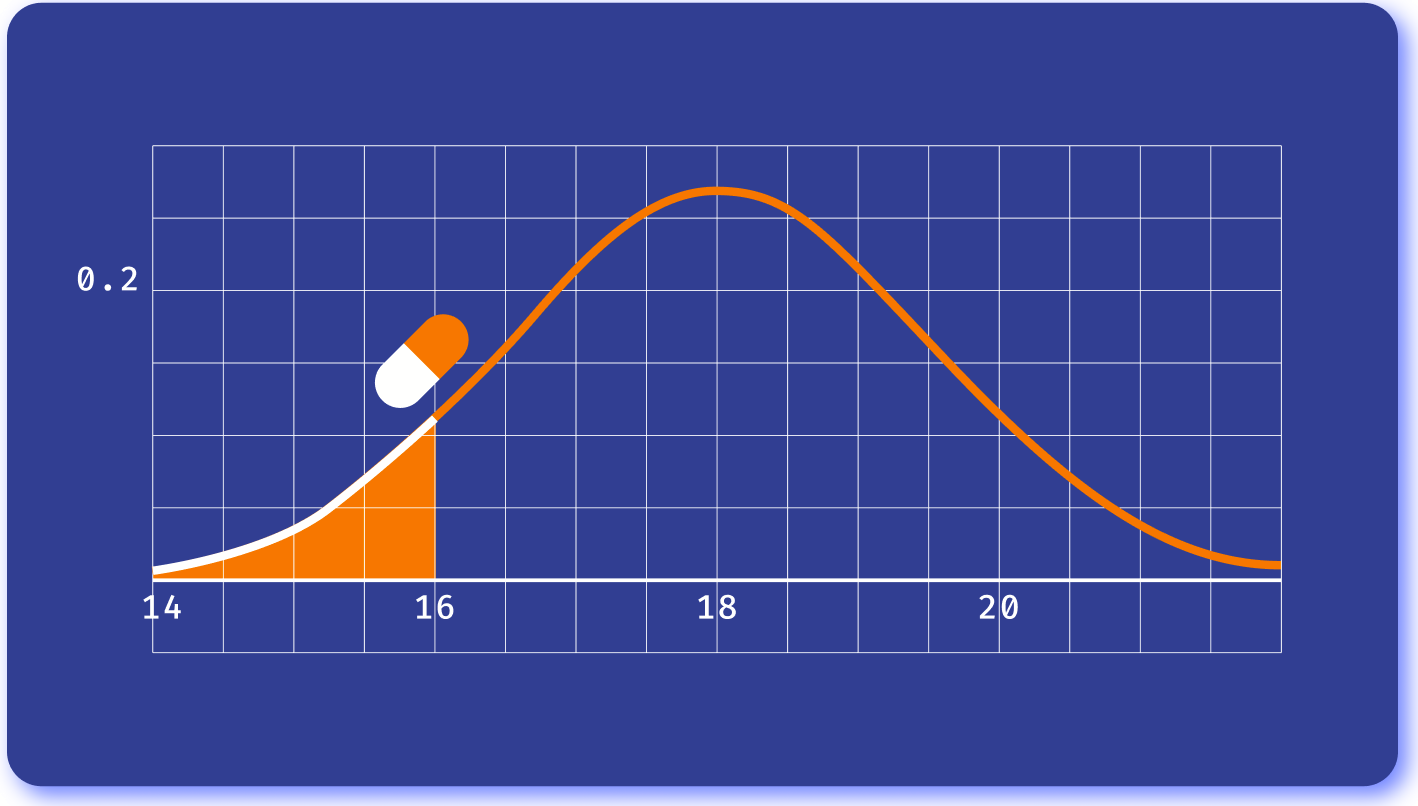

In [ ]:
#@title <b> Рисунок </b>
import gdown
from IPython.display import Image, display
google_drive_url = "https://drive.google.com/file/d/12Vhmqo-Bqt2s3TZyi6rFJFx8GmI0vlZj/view?usp=sharing"
file_id = google_drive_url.split('/')[5]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = 'downloaded_image.png'
gdown.download(download_url, output, quiet=True);
display(Image(output, width=1200))  # Adjust the width as needed


Рисунок 5. Группе, принимавшей препарат, потребовалось 16 дней, чтобы выздороветь

Таким образом, если мы достигнем среднего времени выздоровления в **15,53** дня или меньше в нашей выборке, наш препарат признан статистически значимым, чтобы показать влияние. Однако наше среднее время выздоровления составляет **16** дней и не попадает в зону критики для нулевой гипотезы. Поэтому, тест на статистическую значимость **не пройден**. Область до этой **16-дневной** отметки — наше p-значение, которое составляет **0,0912**, и мы рассчитываем его в **Python**, как показано в *примере 7*. Поскольку **p-значение 0,0912** больше нашего порога статистической значимости **0,05**, мы *не считаем испытание лекарства успешным* и не отвергаем нулевую гипотезу.

In [ ]:
# Пример 7. Расчет однохвостого p-значения
from scipy.stats import norm
# Простуда имеет среднее время выздоровления 18 дней, стандартное отклонение 1,5
mean = 18
std_dev = 1.5
# Вероятность 16 или меньше дней
p_value = norm.cdf(16, mean, std_dev)
print(p_value) # 0.09121121972586788

0.09121121972586788


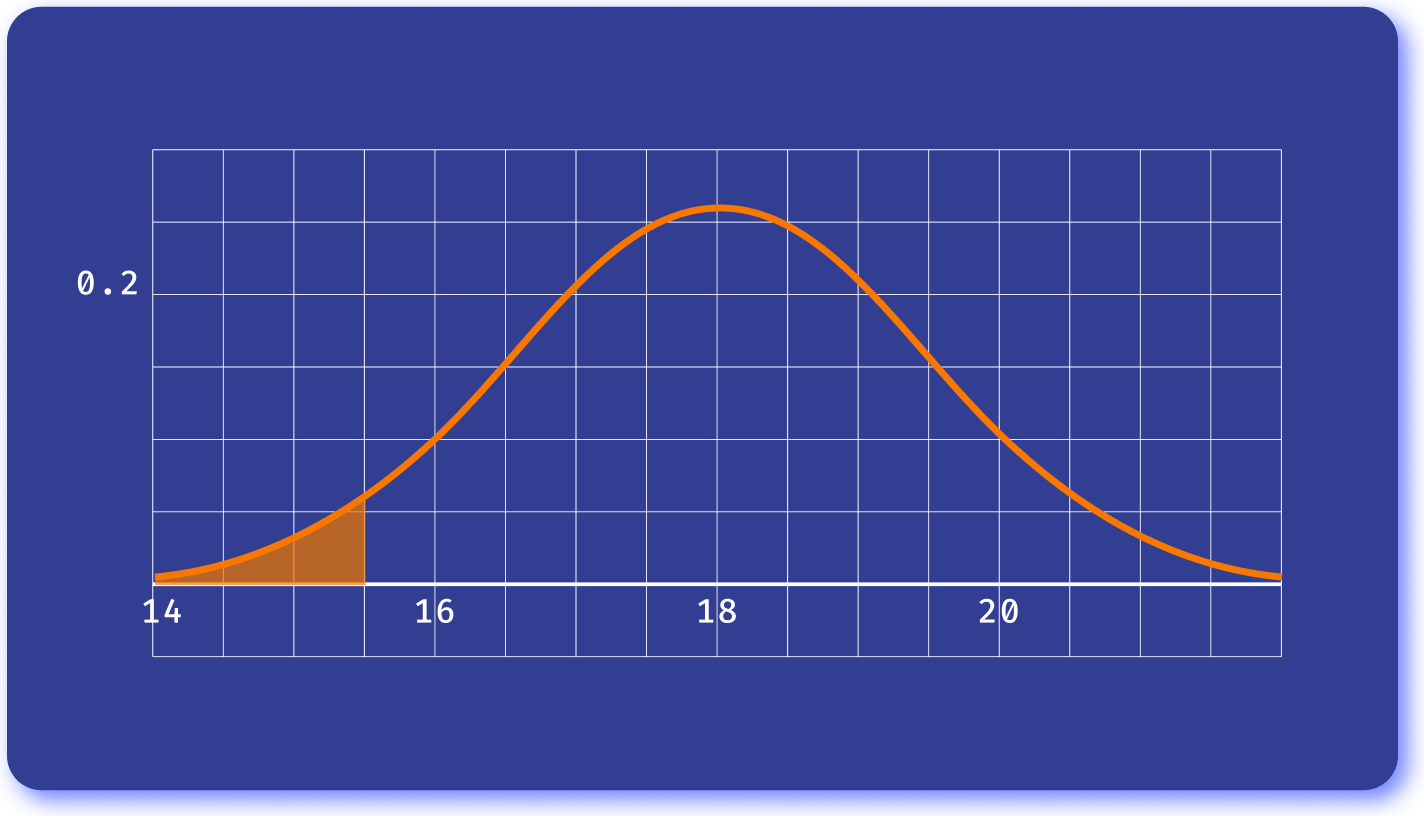

In [ ]:
#@title <b> Рисунок </b>
import gdown
from IPython.display import Image, display
google_drive_url = "https://drive.google.com/file/d/1V02sKKbua7XnrjxpFyh5zhvxgildcb6b/view?usp=sharing"
file_id = google_drive_url.split('/')[5]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = 'downloaded_image.png'
gdown.download(download_url, output, quiet=True);
display(Image(output, width=1200))  # Adjust the width as needed

Рисунок 6. Получение значения x c "5% площади за ним"

# Тест с двумя хвостами

Предыдущий тест, который мы проводили, называется **однохвостым**, так как искал **статистическую значимость** только на одном хвосте. Однако часто безопаснее и лучше использовать двухвостый тест. Мы объясним почему, но сначала проведем расчет.

Для проведения двухвостого теста мы формулируем **нулевую** и **альтернативную гипотезы** в структуре «равно» и «не равно». В нашем тесте лекарства мы скажем, что **нулевая гипотеза** имеет среднее время выздоровления в 18 дней. Но альтернативная гипотеза заключается в том, что среднее время выздоровления не равно **18** дням благодаря новому лекарству:

**H0**: среднее значение выборки = **18**

**H1**: среднее значение выборки ≠ **18**

Это имеет важное значение. Мы формулируем **альтернативную гипотезу** не для проверки уменьшения времени выздоровления от простуды с помощью лекарства, а чтобы понять, оказывает ли **оно вообще какое-либо влияние**. Это включает проверку увеличения продолжительности простуды 😀

Естественно, это означает, что мы распределяем наш порог значимости **p-значения** на оба хвоста, а не только на один. Если мы тестируем на статистическую значимость **5%**, то делим это пополам и даём каждому хвосту по **2,5%**. Если среднее время выздоровления с нашим лекарством попадает в любую из этих областей, наш тест успешен, и мы отвергаем нулевую гипотезу (*рисунок 7*). Значения $x$ для нижнего и верхнего хвостов составляют **15,06** и **20,93** соответственно. Это означает, что если мы окажемся ниже или выше этих значений, соответственно, то отвергнем нулевую гипотезу. Эти значения рассчитываются с использованием обратной CDF, как показано на *рисунке 8* и в *примере 8*. Помните, чтобы получить значение для верхнего хвоста, мы берем **0,95** и затем добавляем к нему кусок значимости в **0,025**, получая **0,975**.





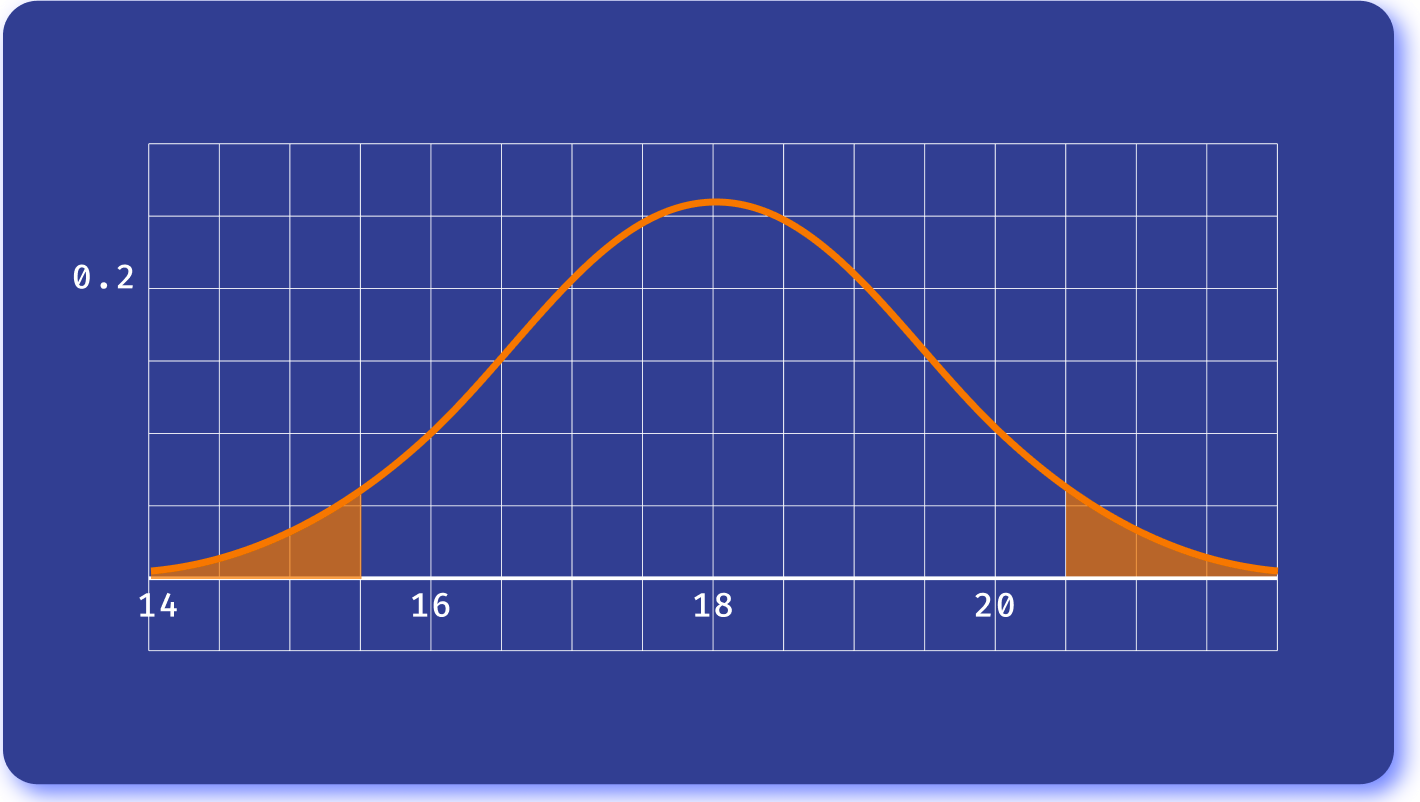

In [ ]:
#@title <b> Рисунок </b>
import gdown
from IPython.display import Image, display
google_drive_url = "https://drive.google.com/file/d/1_cpVwxGcvE7dVN4_zYB0dfRzES61bWYV/view?usp=sharing"
file_id = google_drive_url.split('/')[5]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = 'downloaded_image.png'
gdown.download(download_url, output, quiet=True);
display(Image(output, width=1200))  # Adjust the width as needed


Рисунок 7. Тест с двумя хвостами

In [ ]:
# Пример 8
from scipy.stats import norm
# Простуда имеет среднее время выздоровления 18 дней, стандартное отклонение 1,5
mean = 18
std_dev = 1.5
# Какое x-значение имеет 2,5% области за ним?
x1 = norm.ppf(.025, mean, std_dev)
# Какое x-значение имеет 97,5% области за ним?
x2 = norm.ppf(.975, mean, std_dev)
print(x1) # 15.060054023189918
print(x2) # 20.93994597681008

15.060054023189918
20.93994597681008


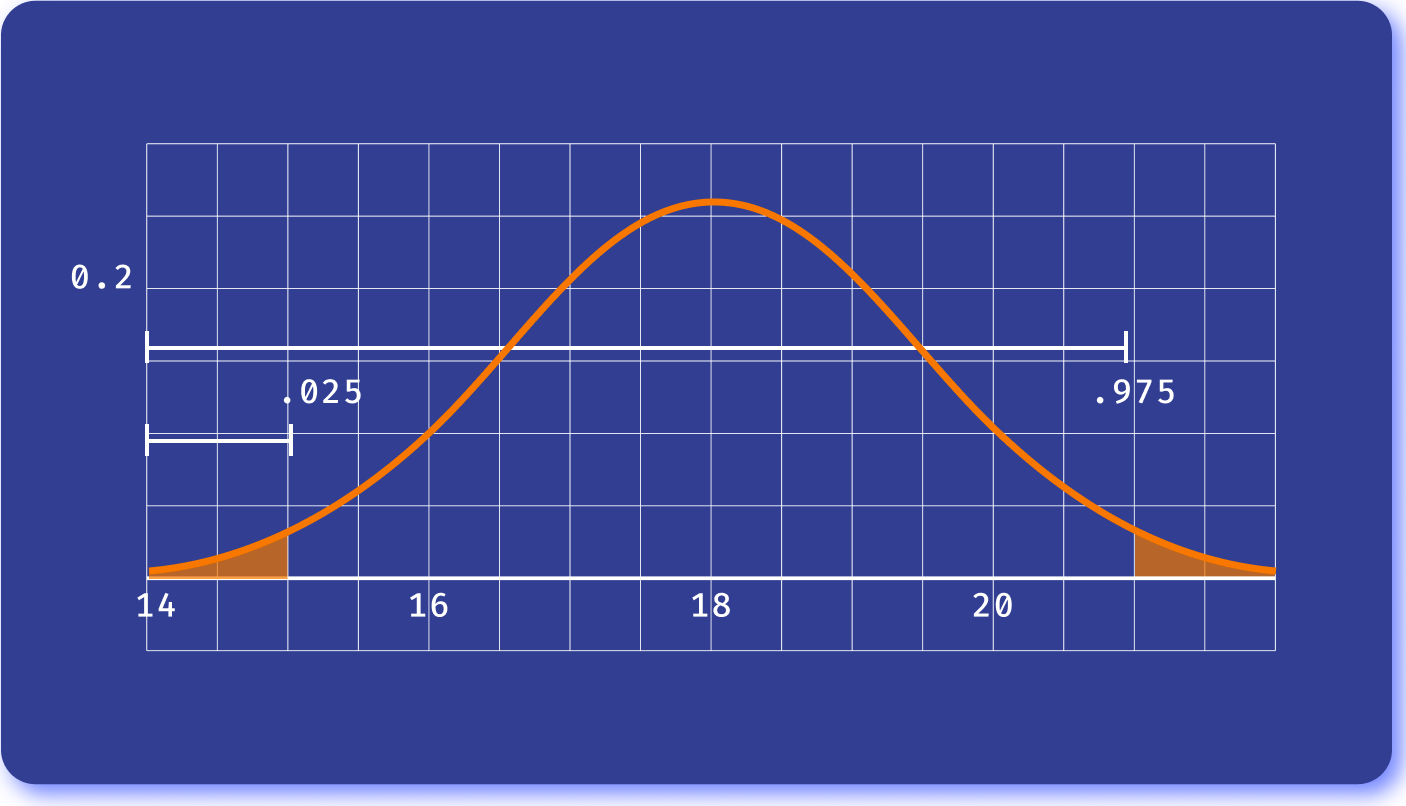

In [ ]:
#@title <b> Рисунок </b>
import gdown
from IPython.display import Image, display
google_drive_url = "https://drive.google.com/file/d/1j0Pkhn0IZgN4YMw8-pqCu3e3aEdDn04C/view?usp=sharing"
file_id = google_drive_url.split('/')[5]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = 'downloaded_image.png'
gdown.download(download_url, output, quiet=True);
display(Image(output, width=1200))  # Adjust the width as needed

Рисунок 8. Расчет **95%** зоны распределения

Среднее значение выборки для тестовой группы с лекарством составляет **16**, и **16** не меньше **15,06** и не больше **20,9399**. Таким образом, как и в случае однохвостого теста, мы не отвергаем нулевую гипотезу. Наш препарат все еще не показал никакой **статистической значимости** для воздействия, как показано на *рисунке 8*. Но каково **p-значение**? Здесь **двухвостый тест** становится интересным. Наш **p-значение** будет учитывать не только область слева от **16**, но и симметричную область на правом хвосте (**x-значение** 20). Это учитывает вероятность события или более редкого на обеих сторонах колоколообразной кривой. Когда мы суммируем обе эти области, у нас получается **p-значение 0,1824**. Это значительно больше пpогового **p-значения 0,05**, так что оно определённо не попадает под наш порог значимости.



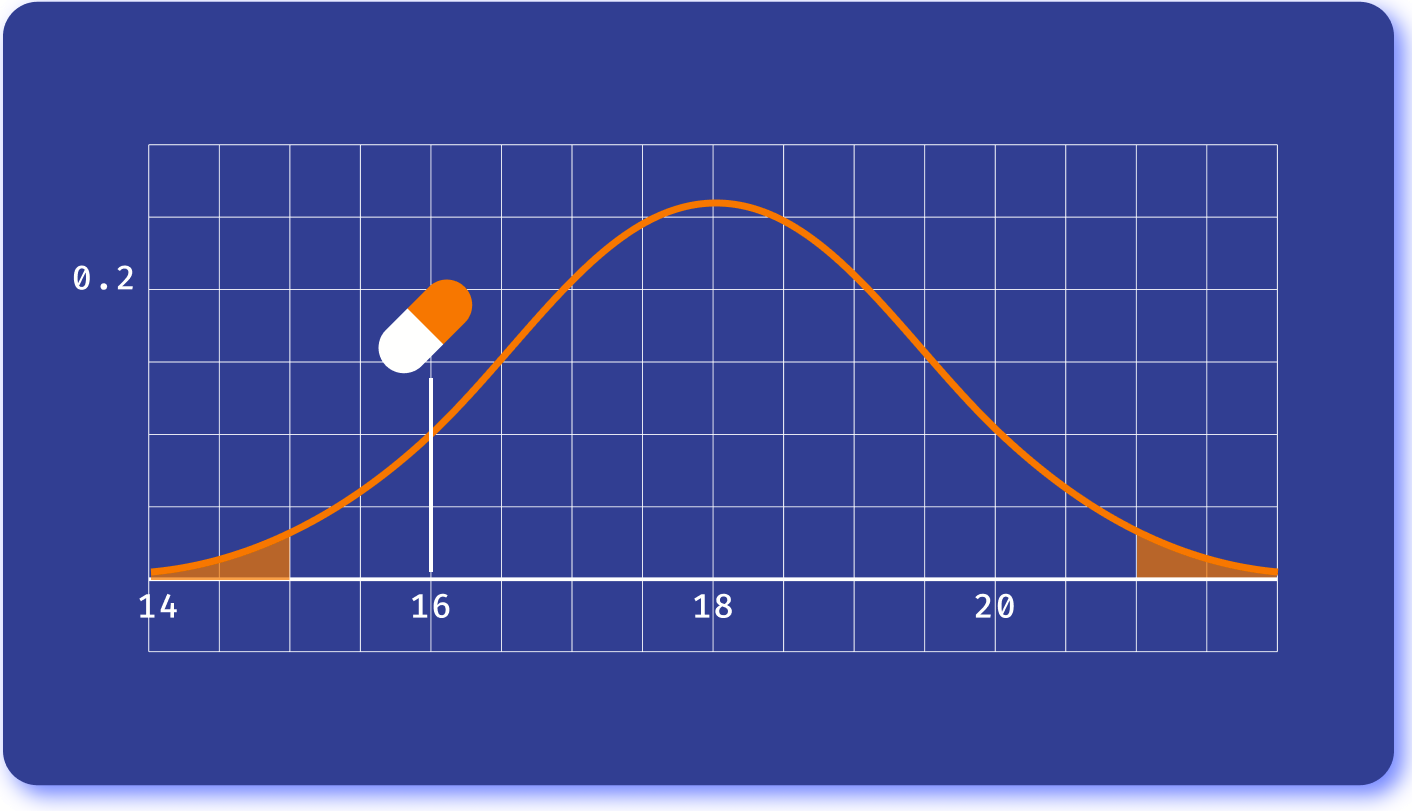

In [ ]:
#@title <b> Рисунок </b>
import gdown
from IPython.display import Image, display
google_drive_url = "https://drive.google.com/file/d/11Q-LgRSzhJmBfdY4yt2TuMU1EPdC8Utg/view?usp=sharing"
file_id = google_drive_url.split('/')[5]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
output = 'downloaded_image.png'
gdown.download(download_url, output, quiet=True);
display(Image(output, width=1200))  # Adjust the width as needed

Рисунок 9. Двусторонний тест не смог доказать статистическую значимость.

In [ ]:
# Пример 9. Расчет двустороннего p-значения
from scipy.stats import norm
# Простуда имеет среднее время выздоровления 18 дней, стандартное отклонение 1,5
mean = 18
std_dev = 1.5
# Вероятность 16 или меньше дней
p1 = norm.cdf(16, mean, std_dev)
# Вероятность 20 или больше дней
p2 = 1.0 - norm.cdf(20, mean, std_dev)
# P-значение для обеих сторон
p_value = p1 + p2
print(p_value) # 0.18242243945173575

0.18242243945173575


Почему мы также добавляем симетричную область на противоположной стороне в **двустороннем тесте**? Это может быть не самым интуитивным для понимания понятием, но сначала вспомните, как мы структурировали наши **гипотезы**:

**H0**: среднее значение выборки = **18**

**H1**: среднее значение выборки ≠ **18**

Если мы проверяем гипотезу в рамках **"равно 18"** против **"не равно 18"**, мы должны учитывать любую **вероятность**, **равную** или меньшую на обеих сторонах. В конце концов, мы пытаемся доказать значимость, и это включает любой результат, который **равнозначно** или **менее вероятен**. У нас не было этого рассмотрения в **однохвостом **тесте, который использовал только логику **"больше/меньше"**. Но когда мы рассматриваем "равно/не равно", наша область интереса идет в обе стороны.

Каковы практические последствия **двухвостого теста**? Как это влияет на то, отвергаем ли мы нулевую гипотезу? Задайте себе следующий вопрос: какой тест устанавливает более **высокий порог**? Вы заметите, что даже если наша цель показать **уменьшение** чего-либо (например, время выздоровления от простуды), **переформулировка гипотезы** с целью подтвердить любое воздействие (уменьшение или увеличение) устанавливает более высокий **порог значимости**. Если наш порог значимости составляет **p-значение 0,05** или ниже, наш однохвостый тест был ближе к принятию с **p-значением 0,0912** по сравнению с **двусторонним тестом**, который был практически в два раза больше с **p-значением 0,182**.

Это означает, что двусторонний тест делает более трудным отвергнуть **нулевую гипотезу** и требует более веских доказательств, чтобы пройти тест. Также подумайте об этом: что если наше лекарство может ухудшить простуду и продлить её продолжительность? Может быть полезно учитывать эту вероятность и учитывать вариацию в этом направлении. Вот почему **двусторонние тесты** предпочтительнее в большинстве случаев. Они, как правило, более надежны и не склонны предвзято формулировать гипотезу в одном направлении. **Таким образом мы не может сказать, что это лекарство работает**.




# Остерегайтесь p-хакинга!

В научном сообществе осознание проблемы, называемой **p-хакинга**, где исследователи подбирают статистически значимые **p-значения 0,05** или ниже, продолжает расти. Это несложно сделать с большими данными, машинным обучением и анализом данных, где можно исследовать сотни или тысячи переменных и затем находить значимые (**но случайные**) связи между ними.

Почему так много исследователей занимается **p-хакинг**? Многие, вероятно, не осознают, что они это делают. Легко продолжать настраивать модель, исключая "шумные" данные и изменяя **параметры**, пока она не даст "правильный" результат. Другие просто находятся под давлением со стороны академического мира и индустрии, чтобы выдавать выгодные, а не объективные результаты.

Хороший разбор на эту тему можно посмотреть здесь:
https://www.youtube.com/watch?v=42QuXLucH3Q

# Распределение Стьюдента: работа с малыми выборками

Рассмотрим работу с выборками, состоящими из **30** или **менее элементов**. Отметим, что граница в **30** элементов выборки является **условной** (это просто некоторое **эврестическое правило**). При расчете **доверительных интервалов** или **проверке гипотез**, если размер выборки составляет **30** или **меньше**, предпочтительнее использовать **t-распределение** вместо нормального распределения. **t-распределение** аналогично нормальному распределению, но имеет более **"толстые" хвосты**, что учитывает большую дисперсию и неопределенность.

На *рисунке 10* показано **нормальное распределение** (**пунктирная линия**) рядом с **t-распределением** со степенью свободы, равной единице (сплошная линия). Чем меньше размер выборки, тем более выражены хвосты у **t-распределения**. Однако по мере увеличения числа элементов в выборке до **31 и более**, **t-распределение** становится практически неотличимым от **нормального распределения**, что подтверждает идеи, описанные центральной предельной теоремой. Обратите внимание, что параметр "степени свободы" (*англ. degree of freedom - df*) равен количеству элементов выборки минус один.

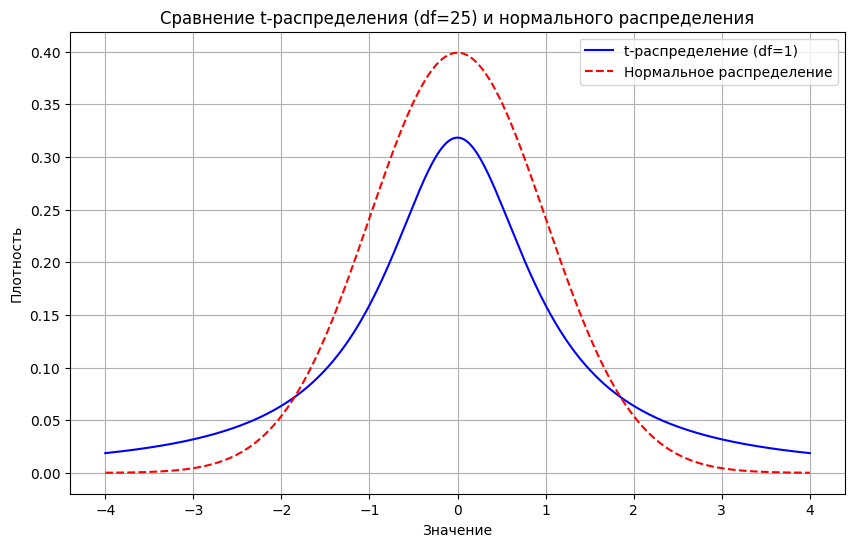

In [ ]:
#@title <b> Рисунок </b>
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Параметры
df = 1  # степени свободы для t-распределения
mean = 0  # среднее для нормального распределения
std_dev = 1  # стандартное отклонение для нормального распределения

# Генерируем данные для графика
x = np.linspace(-4, 4, 1000)

# Плотности вероятности
y_t = stats.t.pdf(x, df)
y_norm = stats.norm.pdf(x, mean, std_dev)

# Создаем график
plt.figure(figsize=(10, 6))
plt.plot(x, y_t, label=f't-распределение (df={df})', color='blue')
plt.plot(x, y_norm, label='Нормальное распределение', color='red', linestyle='--')

# Устанавливаем названия осей и заголовок на русском
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.title('Сравнение t-распределения (df=25) и нормального распределения')
plt.legend()

# Отображаем график
plt.grid(True)
plt.show()

Рисунок 10. t-распределение наряду с нормальным распределением; обратите внимание на более толстые хвосты

In [ ]:
# Пример 10
from scipy.stats import t
# получение критического диапазона значений для 95%-ного доверительного интервала
# при размере выборки 25
n = 25
lower = t.ppf(.025, df=n-1)
upper = t.ppf(.975, df=n-1)
print(lower, upper)

-2.063898561628021 2.0638985616280205
